In [1]:

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import fsps
from tqdm import tqdm
from astropy import constants as const
tiny_number = 1e-70

from ceridwen.ssps.ssp_data import SSPData
from ceridwen.csp.csp import CSPBasis, fnu2flam

T_UNIV = 13.8  # Gyr, age of the universe
N_T = 100     # number of time steps for SFH

def gaussian_burst(tau, center_tau, width_tau, amp=1.0):
    """Gaussian in lookback time, evaluated on tau grid (Gyr)."""
    return amp * jnp.exp(-0.5 * ((tau - center_tau) / width_tau)**2)

t = jnp.linspace(1e-2, T_UNIV, N_T)   # Gyr (avoid exactly 0)
tau = T_UNIV - t                      # lookback time (Gyr)

sfr_bimodal = (gaussian_burst(tau, 0.05, 0.03, 1.0) +
               gaussian_burst(tau, 11.0, 0.8, 0.7))
zh = jnp.full_like(t, 0.02)  # constant metallicity (Z=0.02)

ssp_data = SSPData.load('/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/ssp_data.h5')


#-------------------------------
# DUSTY FSPS SPECTRUM
#-------------------------------
sp = fsps.StellarPopulation(zcontinuous=1, zmet=1, add_neb_emission=False, add_neb_continuum=False)

In [2]:
wave, fsps_spec = sp.get_spectrum(tage=0.001)

sp.params['add_neb_emission'] = True
sp.params['add_neb_continuum'] = True

wave, fsps_spec_with_neb = sp.get_spectrum(tage=0.001)

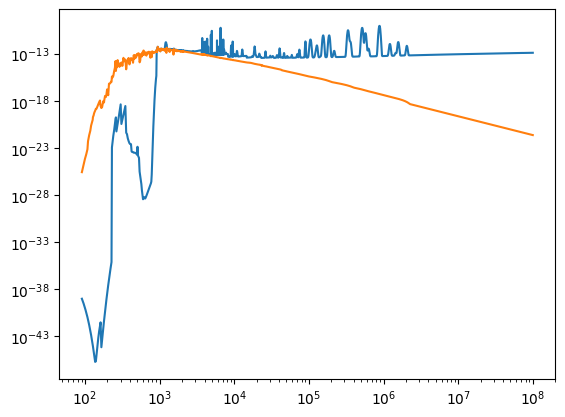

In [4]:
plt.loglog(wave, fsps_spec_with_neb, label='With Nebular Emission')

plt.loglog(wave, fsps_spec, label='With Nebular Emission')


In [7]:
print(sp.params['gas_logu'], sp.params['gas_logz']
)

-2 0.0


In [8]:
#sp.set_tabular_sfh(age = np.asarray(t), sfr = np.asarray(sfr_bimodal))
sp.params['add_neb_emission'] = False
sp.params['add_neb_continuum'] = False
sp.params['zmet'] = 10
wave, fsps_no_neb_spec= sp.get_spectrum(tage=13.8) 

sp.params['add_neb_emission'] = True
sp.params['add_neb_continuum'] = True

sp.params['gas_logz'] = -1.0
sp.params['gas_logu'] = -2.5
sp.params['zmet'] = 10
wave, fsps_spec= sp.get_spectrum(tage=13.8)

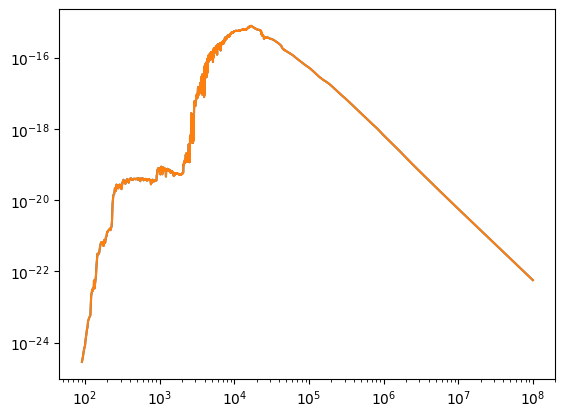

In [25]:
diffdust = 0.2
diffdust_index = -0.7
young_dust = 0.2
young_dust_index = -1

dust_params = {'tau_pow': young_dust,
                'alpha': -young_dust_index, 'tau_kc': 0.0, 'dust_index': 0.0,
                'diffuse_params': {'tau_kc': diffdust, 'dust_index': diffdust_index}}
emi_params = {'duste_qpah': 0.5, 
              'duste_umin': 1.0, 
              'duste_gamma': 0.01}
#-------------------------------
# CSP SPECTRUM WITH DUST
#-------------------------------
zh = jnp.full_like(t, 10**ssp_data.ssp_lgmet[0])  # constant metallicity (Z=0.02)
csp = CSPBasis(ssp_data, dusty=True, dust_params={'bin_edges': [(-jnp.inf, -1.97), (-1.97, 10)], 'laws': ['powerlaw', 'kriek_conroy']})
print(csp.dust.get_default_fit_params())
csp.add_sfh(sfh=ssp_data.ssp_lg_age_gyr[1], lookback_time=0.001)
csp.add_zh(ssp_data.ssp_lgmet[1], lookback_time=0.001)
spec = csp.get_spectrum(dust_params=dust_params, emi_params=emi_params)
spec_dustfree = csp.get_spectrum_dustfree()


{'tau_pow': 1.0, 'alpha': 1.0, 'tau_kc': 1.0, 'dust_index': 0.0, 'diffuse_params': {'tau_kc': 1.0, 'dust_index': 0.0}}
lookback time
lookback time
No times added for metallicity history, use lookback_time or forward_time of SFH


IndexError: Too many indices: 0-dimensional array indexed with 1 regular index.

In [20]:
import matplotlib.pyplot as plt

# Convert to flam
fsps_no_neb_flam = fnu2flam(wave, fsps_no_neb_spec * 1e-23 * 3631)
fsps_with_neb_flam = fnu2flam(wave, fsps_spec * 1e-23 * 3631)
ceridwen_no_neb_flam = fnu2flam(wave, spec_dustfree * 1e-23 * 3631)
ceridwen_with_neb_flam = fnu2flam(wave, spec * 1e-23 * 3631)

# Compute residuals
residual_no_neb = (fsps_no_neb_flam - ceridwen_no_neb_flam) / ceridwen_no_neb_flam
residual_with_neb = (fsps_with_neb_flam - ceridwen_with_neb_flam) / ceridwen_with_neb_flam

# Make figure with 2 vertically stacked subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})

# Main SED plot (top)
ax1.loglog(wave, fsps_no_neb_flam, ls='--', zorder=100, color='pink', label='FSPS without nebular emission')
ax1.loglog(wave, fsps_with_neb_flam, ls='--', zorder=100, color='crimson', label='FSPS with nebular emission')
ax1.loglog(wave, ceridwen_no_neb_flam, color='dodgerblue', label='Ceridwen no nebular emission')
#ax1.loglog(wave, ceridwen_with_neb_flam, color='navy', label='Ceridwen with nebular emission')

ax1.set_ylabel(r'$\lambda F_\lambda$ (erg s$^{-1}$ cm$^{-2}$)')
ax1.legend()
ax1.set_xlim(1e2, 1e6)
ax1.set_ylim(1e-20, 1e-12)

# Residual subplot (bottom)
ax2.plot(wave, residual_no_neb, color='dodgerblue', label='(FSPS - Ceridwen) / Ceridwen (no neb)')
ax2.plot(wave, residual_no_neb, color='pink', ls='--', label='(FSPS - Ceridwen) / Ceridwen (no neb)')
#ax2.plot(wave, residual_with_neb, color='crimson', ls='--', label='(FSPS - Ceridwen) / Ceridwen (with neb)')
ax2.axhline(0, color='gray', lw=1, ls=':')  # Reference line

ax2.set_xscale('log')
ax2.set_xlabel('Wavelength (Angstrom)')
ax2.set_ylabel('Rel. Residual')
ax2.set_ylim(-0.5, 0.5)
ax2.legend()

plt.tight_layout()
plt.show()

NameError: name 'fsps_no_neb_spec' is not defined

In [21]:

import jax.numpy as jnp
from pathlib import Path
from jax import vmap, jit
#from jax.scipy.interpolate import interp1d
import numpy as np
import astropy.constants as const
import math



from pathlib import Path
import jax.numpy as jnp

class NebularModel:
    def __init__(self, isoc_type, cloudy_dust, sps_home, csp_lambda,
                 mypi, smooth_velocity=True, nebnz=11, nebnage=10, nebnip=7, nebular_smooth_init=100.0):
        """
        Initializes a nebular emission model for use with stellar population synthesis output.

        Parameters
        ----------
        isoc_type : str
            Isochrone type (e.g., 'mist', 'pdva', 'bpss') used to identify the correct nebular files.
        cloudy_dust : bool
            If True, uses nebular models with dust attenuation from CLOUDY.
        sps_home : str or Path
            Path to the FSPS root directory containing the nebular subdirectory.
        csp_lambda : array-like
            Wavelength grid of the composite stellar population (CSP) spectrum [in Angstrom].
.
        mypi : float
            Value of π (can be jnp.pi or float).
        smooth_velocity : bool, optional
            If True, smoothing is velocity-based (km/s). If False, use fixed smoothing in Å.
        nebnz : int, optional
            Number of metallicity grid points.
        nebnage : int, optional
            Number of age grid points.
        nebnip : int, optional
            Number of ionization parameter grid points.
        nebular_smooth_init : float, optional
            Initial smoothing width in km/s or Å (depending on `smooth_velocity`).
        """

        # Store CSP wavelength grid and spectrum length
        self.csp_lambda = jnp.asarray(csp_lambda)
        self.nspec = self.csp_lambda.size

        # Store constants and hyperparameters
        self.mypi = mypi
        self.smooth_velocity = smooth_velocity
        self.nebular_smooth_init = nebular_smooth_init
        self.nebnz = nebnz
        self.nebnage = nebnage
        self.nebnip = nebnip

        # Set filenames for nebular continuum and line emission based on isochrone type and dusty flag
        suffix = 'WD' if cloudy_dust else 'ND'
        base = Path(sps_home) / 'nebular' / f'ZAU_{suffix}_{isoc_type}'
        self.cont_file = base.with_suffix('.cont')   # Nebular continuum file
        self.line_file = base.with_suffix('.lines')  # Nebular emission line file

        # Load the nebular continuum cube and grids
        self._load_continuum()

        # Load the nebular emission line cube and line positions
        self._load_lines()

        # Compute the minimum spectral resolution for each line (in Å)
        self._compute_resolution_elements()

        # Build Gaussian line profiles for all emission lines on the CSP wavelength grid
        self._build_gaussians()

    def __repr__(self):
        def _shape(x):
            try:
                return tuple(jnp.asarray(x).shape)
            except Exception:
                try:
                    return tuple(np.asarray(x).shape)
                except Exception:
                    return "n/a"

        def _minmax(x):
            try:
                xa = jnp.asarray(x)
                return f"{float(jnp.min(xa)):.4g} – {float(jnp.max(xa)):.4g}"
            except Exception:
                return "n/a"

        lines = []
        lines.append("<NebularModel>")
        lines.append("-----------------------------------")
        # Config
        lines.append(f"Files:")
        lines.append(f"  Continuum: {str(self.cont_file)}")
        lines.append(f"  Lines    : {str(self.line_file)}")
        lines.append("")
        lines.append("Grids & settings:")
        lines.append(f"  CSP λ grid shape        : {_shape(self.csp_lambda)}  (nspec={getattr(self, 'nspec', 'n/a')})")
        lines.append(f"  smooth_velocity         : {self.smooth_velocity}")
        lines.append(f"  nebular_smooth_init     : {self.nebular_smooth_init}")
        lines.append(f"  nebnz / nebnage / nebnip: {getattr(self, 'nebnz', 'n/a')} / {getattr(self, 'nebnage', 'n/a')} / {getattr(self, 'nebnip', 'n/a')}")
        lines.append("")
        # Continuum cube + parameter grids
        lines.append("Continuum cube (log10 L/Q):")
        lines.append(f"  nebem_cont shape        : {_shape(getattr(self, 'nebem_cont', None))}  (nspec, nz, nage, nu)")
        lines.append(f"  nebem_logz shape/range  : {_shape(getattr(self, 'nebem_logz', None))} ; {_minmax(getattr(self, 'nebem_logz', None))}")
        lines.append(f"  nebem_age  shape/range  : {_shape(getattr(self, 'nebem_age', None))}  ; {_minmax(getattr(self, 'nebem_age', None))}  (log10 yr)")
        lines.append(f"  nebem_logu shape/range  : {_shape(getattr(self, 'nebem_logu', None))} ; {_minmax(getattr(self, 'nebem_logu', None))}")
        lines.append("")
        # Lines cube
        lines.append("Emission lines (log10 L/Q):")
        lines.append(f"  line positions shape    : {_shape(getattr(self, 'nebem_line_pos', None))}  (Å)")
        lines.append(f"  nebem_line shape        : {_shape(getattr(self, 'nebem_line', None))}  (nlines, nz, nage, nu)")
        lines.append(f"  neb_res_min shape/range : {_shape(getattr(self, 'neb_res_min', None))} ; {_minmax(getattr(self, 'neb_res_min', None))}  (Å)")
        lines.append("")
        # Precomputed Gaussians
        lines.append("Precomputed line profiles:")
        lines.append(f"  gaussnebarr shape       : {_shape(getattr(self, 'gaussnebarr', None))}  (nspec, nlines)")
        lines.append("")
        # Last evaluation (if present)
        lines.append("Last evaluation buffers (optional):")
        lines.append(f"  conflux shape           : {_shape(getattr(self, 'conflux', None))}")
        lines.append(f"  lineflux shape          : {_shape(getattr(self, 'lineflux', None))}")
        lines.append(f"  linespec shape          : {_shape(getattr(self, 'linespec', None))}")

        return "\n".join(lines)

    def _load_continuum(self): 
        # Open the nebular continuum file and skip the header
        with open(self.cont_file, 'r') as f:
            f.readline()  # skip header line

            # Read the wavelength grid of the nebular continuum model
            readlambneb = np.array([float(x) for x in f.readline().split()])
            nlam = len(readlambneb)
            self.readlambneb = jnp.asarray(readlambneb)

            # Read the rest of the file content into memory
            lines = f.readlines()

            # Allocate arrays for interpolated continuum and parameter grids
            cont_cube = np.zeros((self.nspec, self.nebnz, self.nebnage, self.nebnip))
            logz_grid = np.zeros(self.nebnz)   # gas metallicity
            logu_grid = np.zeros(self.nebnip)  # ionization parameter
            age_grid = np.zeros(self.nebnage)  # age in yr

            idx = 0  # line index in the file
            for i in range(self.nebnz):
                for j in range(self.nebnage):
                    for k in range(self.nebnip):
                        # First line gives (logZ, age, logU) for this cube slice
                        parts = [float(x) for x in lines[idx].split()]
                        logz_grid[i], age_grid[j], logu_grid[k] = parts[:3]
                        idx += 1

                        # Second line gives the continuum spectrum (Lsun/Hz/Q)
                        cont = np.array([float(x) for x in lines[idx].split()])
                        logcont = np.log10(cont + 10**-95)  # avoid log(0)
                        # Interpolate onto CSP wavelength grid
                        cont_interp = jnp.interp(self.csp_lambda, readlambneb, logcont)
                        cont_cube[:, i, j, k] = cont_interp
                        idx += 1

        # Store as JAX arrays for GPU compatibility
        self.nebem_cont = jnp.asarray(cont_cube)
        self.nebem_logz = jnp.asarray(logz_grid)
        self.nebem_logu = jnp.asarray(logu_grid)
        self.nebem_age = jnp.log10(jnp.asarray(age_grid))  # log10(age/yr)
    
    def _load_lines(self):
        # Open the nebular emission line file
        with open(self.line_file, 'r') as f:
            f.readline()  # Skip header line

            # Read the rest-frame line center wavelengths (in Å)
            self.nebem_line_pos = jnp.array([float(x) for x in f.readline().split()])
            self.nemline = self.nebem_line_pos.shape[0]

            # Allocate array to store log10(line luminosities) in Lsun/Q
            line_cube = np.zeros((self.nemline, self.nebnz, self.nebnage, self.nebnip))

            # Loop over metallicity, age, and ionization parameter grid
            for i in range(self.nebnz):
                for j in range(self.nebnage):
                    for k in range(self.nebnip):
                        f.readline()  # metadata line (logZ, age, logU), already known
                        linevals = np.array([float(x) for x in f.readline().split()])
                        # Store log10(L/Q), avoiding log(0)
                        line_cube[:, i, j, k] = np.log10(linevals + 10**-95)

            # Store line emission cube as a JAX array for GPU use
            self.nebem_line = jnp.asarray(line_cube)

    
    def _compute_resolution_elements(self):
        '''Avoid delta function spikes in nebular lines when the broadening of the gaussian is smaller than the resolution element.'''
        # For each emission line, find the nearest wavelength index just below the line center
        idx = jnp.clip(
            jnp.searchsorted(self.csp_lambda, self.nebem_line_pos) - 1,
            1, self.nspec - 2 
        )
        
        # Estimate the local spectral resolution element Δλ around each line
        dlam = self.csp_lambda[idx + 1] - self.csp_lambda[idx]

        # Store the minimum resolution per line as a JAX array
        self.neb_res_min = jnp.asarray(dlam)

    
    def _build_gaussians(self):
        """
        Precompute normalized Gaussian line profiles for each emission line,
        on the given wavelength grid. These profiles model the line broadening
        (either in velocity space or wavelength space), and are stored for
        later use when adding line emission to the SED.
        """

        def compute_line(i):
            lam0 = self.nebem_line_pos[i]
            dlam = jnp.where(
                self.smooth_velocity,
                lam0 * self.nebular_smooth_init / (const.c *10**10)* 1e13,  # in Angstrom
                self.nebular_smooth_init
            )
            dlam = jnp.maximum(dlam, self.neb_res_min[i] * 2.0)

            norm = 1.0 / (jnp.sqrt(2 * jnp.pi) * dlam)
            profile = jnp.exp(-0.5 * ((self.csp_lambda - lam0) / dlam) ** 2)
            scaling = lam0 ** 2 / (const.c * 10**10)

            return norm * profile * scaling  # shape: (n_lambda,)

        # Vectorize over all emission lines
        self.gaussnebarr = jnp.stack([compute_line(i) for i in range(self.nebem_line_pos.shape[0])], axis=1)
        return self.gaussnebarr  # shape: (n_lambda, n_lines)

    def evaluate(self, logZ, logU, logage, logQ):

        # Locate and compute fractional offsets in grid
        z1 = locate(logZ, self.nebem_logz)
        dz = jnp.clip((logZ - self.nebem_logz[z1]) / (self.nebem_logz[z1 + 1] - self.nebem_logz[z1]), 0.0, 1.0)

        u1 = locate(logU, self.nebem_logu)
        du = jnp.clip((logU - self.nebem_logu[u1]) / (self.nebem_logu[u1 + 1] - self.nebem_logu[u1]), 0.0, 1.0)

        a1 = locate(logage, self.nebem_age)
        da = jnp.clip((logage - self.nebem_age[a1]) / (self.nebem_age[a1 + 1] - self.nebem_age[a1]), 0.0, 1.0)
        
        # Interpolate log-continuum and line luminosity
        logcont_interp = trilinear_interp(self.nebem_cont, z1, dz, a1, da, u1, du)
        loglines_interp = trilinear_interp(self.nebem_line, z1, dz, a1, da, u1, du)

        # Combine with logQ
        log_cont_flux = logcont_interp + logQ
        log_line_flux = loglines_interp + logQ
        
        # Convert to linear only where absolutely necessary
        cont_flux = 10 ** log_cont_flux  # shape (nspec,)
        line_flux = 10 ** log_line_flux  # shape (nlines,)
        
        # Combine lines
        line_spec = jnp.dot(self.gaussnebarr, line_flux)   # shape (nspec,)
        self.linespec = line_spec  # Store for later use if needed
        self.conflux = cont_flux  # Store for later use if needed
        self.lineflux = line_flux  # Store for later use if needed

        # Final SED
        spec = cont_flux + line_spec  # both in erg/s/cm²/Å

        return spec

def locate(x, grid):
    return jnp.clip(jnp.searchsorted(grid, x) - 1, 0, grid.size - 2)   

def trilinear_interp(cube, z1, dz, a1, da, u1, du):
    """
    Trilinear interpolation on a 4D cube: shape (nspec, nz, nage, nu)
    """
    # Interpolation weights for the 8 surrounding points
    w = jnp.array([
        (1 - dz) * (1 - da) * (1 - du),
        (1 - dz) * (1 - da) * du,
        (1 - dz) * da * (1 - du),
        (1 - dz) * da * du,
        dz * (1 - da) * (1 - du),
        dz * (1 - da) * du,
        dz * da * (1 - du),
        dz * da * du
    ])

    # Stack the 8 corners along a new axis (0), each of shape (nspec,)
    slices = jnp.stack([
        cube[:, z1,   a1,   u1],
        cube[:, z1,   a1,   u1+1],
        cube[:, z1,   a1+1, u1],
        cube[:, z1,   a1+1, u1+1],
        cube[:, z1+1, a1,   u1],
        cube[:, z1+1, a1,   u1+1],
        cube[:, z1+1, a1+1, u1],
        cube[:, z1+1, a1+1, u1+1]
    ], axis=0)  # shape (8, nspec)

    # Weighted sum over the 8 corners
    return jnp.sum(w[:, None] * slices, axis=0)  # shape (nspec,)


In [22]:
sp.params['gas_logz']

0.0

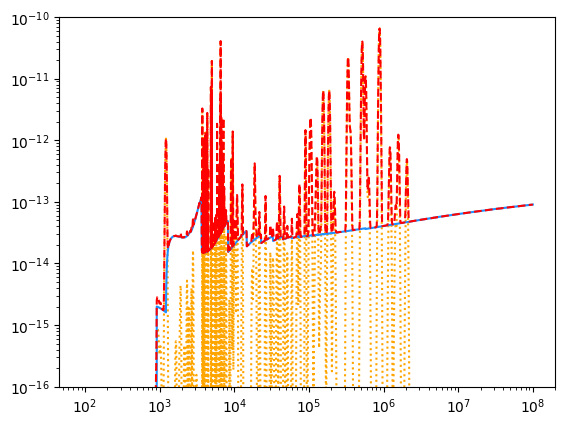

In [23]:

model = NebularModel(
    isoc_type="mist",
    cloudy_dust=False,
    sps_home="/Users/amanda/Prospector/fsps",
    csp_lambda=csp.wave,
    mypi=np.pi,
    nebular_smooth_init=2,
    smooth_velocity=True
)

spec = model.evaluate(
    logZ=-0.0,  # Example metallicity
    logU=-2.0,  # Example ionization parameter
    logage=ssp_data.ssp_lg_age_gyr[1],  # Example age in log years
    logQ=ssp_data.log_qq[1, 1]  # Example ionizing photon rate
)

#plt.plot(model.csp_lambda, model.gaussnebarr, label='Nebular Spectrum', lw=1.5)

#plt.xlim(300, 6100)
plt.ylim(1e-16, 1e-10)
#plt.loglog(csp.wave, spec)

plt.loglog(csp.wave, model.linespec , ls='dotted', color = 'orange')
plt.loglog(csp.wave, model.conflux , ls='-', color='dodgerblue')
plt.loglog(csp.wave, model.conflux + model.linespec, ls='--', color='red')


In [11]:
import jax
import jax.numpy as jnp

# Define the single-evaluation function
def eval_model_for_age(logage, logZ, logU, logQ):
    return model.evaluate(
        logZ=logZ,
        logU=logU,
        logage=logage,
        logQ=logQ,
    )

# Example parameters (broadcasted)
logZ = -0.82
logU = -2.0
logQ_array = ssp_data.log_qq[1, :]   # assume this varies with age
ages = ssp_data.ssp_lg_age_gyr       # shape (N,)

# Vectorize over logage (and optionally logQ)
vmap_eval = jax.vmap(eval_model_for_age, in_axes=(0, None, None, 0))

# Evaluate model for all ages in parallel
spec_array = vmap_eval(ages, logZ, logU, logQ_array)

NameError: name 'model' is not defined

In [12]:
spec_array.shape  # should be (N, nspec)

NameError: name 'spec_array' is not defined

In [13]:
for i in range(spec_array.shape[0]):
    plt.loglog(csp.wave, spec_array[i, :])  # Plot spectrum for each age


NameError: name 'spec_array' is not defined

In [14]:
import matplotlib.pyplot as plt

# Convert to flam
fsps_no_neb_flam = fnu2flam(wave, fsps_no_neb_spec * 1e-23 * 3631)
fsps_with_neb_flam = fnu2flam(wave, fsps_spec * 1e-23 * 3631)
ceridwen_no_neb_flam = fnu2flam(wave, spec_dustfree * 1e-23 * 3631)
ceridwen_with_neb_flam = fnu2flam(wave, spec*1e6 * 1e-23 * 3631)
#lines = fnu2flam(wave, model.linespec*1e6 * 1e-23 * 3631)
all_spec = fnu2flam(wave, jnp.sum(spec_array, axis=0)  * 1e-23 * 3631)
# Compute residuals
residual_no_neb = (fsps_no_neb_flam - ceridwen_no_neb_flam) / ceridwen_no_neb_flam
residual_with_neb = (fsps_with_neb_flam - ceridwen_with_neb_flam) / ceridwen_with_neb_flam

# Make figure with 2 vertically stacked subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})

# Main SED plot (top)
ax1.loglog(wave, fsps_no_neb_flam, ls='--', zorder=100, color='pink', label='FSPS without nebular emission')
ax1.loglog(wave, fsps_with_neb_flam, ls='--', zorder=100, color='crimson', label='FSPS with nebular emission')
ax1.loglog(wave, ceridwen_no_neb_flam, color='dodgerblue', label='Ceridwen no nebular emission')
ax1.loglog(wave, ceridwen_with_neb_flam, color='navy', label='Ceridwen with nebular emission')
ax1.loglog(csp.wave, lines , ls='-', color = 'orange', zorder=0)
ax1.loglog(csp.wave, all_spec , ls=':', color = 'green', label='Ceridwen all ages summed', zorder=0)
ax1.set_ylabel(r'$\lambda F_\lambda$ (erg s$^{-1}$ cm$^{-2}$)')
ax1.legend()
#ax1.set_xlim(1e2, 1e6)
#ax1.set_ylim(1e-20, 1e-12)

# Residual subplot (bottom)
ax2.plot(wave, residual_no_neb, color='dodgerblue', label='(FSPS - Ceridwen) / Ceridwen (no neb)')
ax2.plot(wave, residual_no_neb, color='pink', ls='--')
ax2.plot(wave, residual_with_neb, color='crimson', ls='--', label='(FSPS - Ceridwen) / Ceridwen (with neb)')
ax2.axhline(0, color='gray', lw=1, ls=':')  # Reference line

ax2.set_xscale('log')
ax2.set_xlabel('Wavelength (Angstrom)')
ax2.set_ylabel('Rel. Residual')
ax2.set_yscale('symlog', linthresh=1e-2)
#ax2.set_ylim(-0.5, 0.5)
ax2.legend()

plt.tight_layout()
plt.show()

NameError: name 'fsps_no_neb_spec' is not defined

/var/folders/vd/kv9mg1cx6tdfwmlfx2m5qfr80000gp/T/ipykernel_40511/413153412.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', 7)  # 7 discrete colors


NameError: name 'model' is not defined

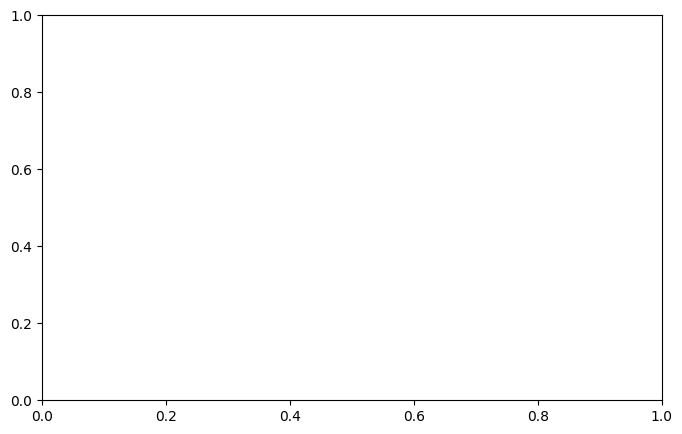

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors

# Setup colormap for 'a' ranging from 0 to 6
cmap = cm.get_cmap('viridis', 7)  # 7 discrete colors
norm = colors.Normalize(vmin=0, vmax=6)

fig, ax = plt.subplots(figsize=(8, 5))

for z in range(11):
    for u in range(10):
        for a in range(7):
            color = cmap(norm(a))
            ax.plot(wave, model.nebem_cont[:, z, u, a], color=color, alpha=0.7)

ax.set_xscale('log')
ax.set_xlabel('Wavelength (Angstrom)')
ax.set_ylabel('Flux')
ax.set_title('Model nebem_cont colored by a')
ax.axvline(9000, color='gray', ls='--', label='9000 Å')
# Optional: Add colorbar to indicate value of 'a'
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, ticks=range(7))
cbar.set_label('a index')

plt.tight_layout()
plt.show()

In [16]:
path = Path('/Users/amanda/Prospector/fsps/nebular/ZAU_WD_mist.cont')
with open(path, 'r') as f:
    header = f.readline()
    print(header)

    readlambneb = np.array([float(x) for x in f.readline().split()])
    nlam = len(readlambneb)
    readlambneb = jnp.asarray(readlambneb)

    lines = f.readlines()
    cont_cube = np.zeros((len(csp.wave), 11, 10, 7))
    logz_grid = np.zeros(11)   # gas metallicity
    logu_grid = np.zeros(7)  # ionization parameter
    age_grid = np.zeros(10)  # age in yr

    idx = 0  # line index in the file
    for i in range(len(logz_grid)):
        for j in range(len(age_grid)):
            for k in range(len(logu_grid)):
                # First line gives (logZ, age, logU) for this cube slice
                parts = [float(x) for x in lines[idx].split()]
                logz_grid[i], age_grid[j], logu_grid[k] = parts[:3]
                idx += 1

                # Second line gives the continuum spectrum (Lsun/Hz/Q)
                cont = np.array([float(x) for x in lines[idx].split()])
                logcont = np.log10(cont + 10**-95)  # avoid log(0)
                # Interpolate onto CSP wavelength grid
                cont_interp = jnp.interp(csp.wave, readlambneb, logcont)
                cont_cube[:, i, j, k] = cont_interp
                idx += 1

#1963 cols 770 rows 11 logZ 10 Age 7 logU



NameError: name 'csp' is not defined

/var/folders/vd/kv9mg1cx6tdfwmlfx2m5qfr80000gp/T/ipykernel_40511/2434090060.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', 7)  # 7 discrete colors


NameError: name 'cont_cube' is not defined

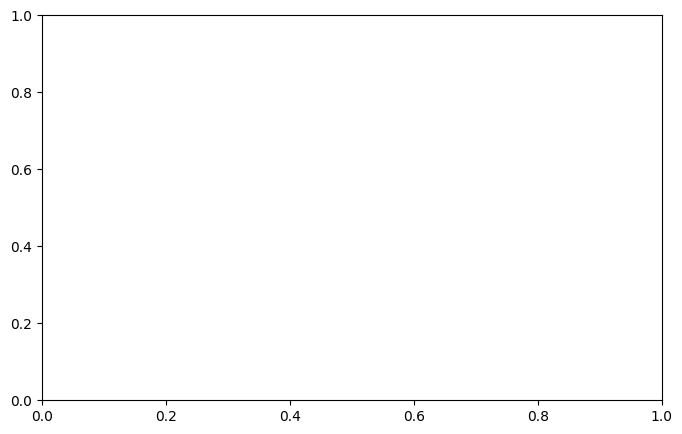

In [17]:
# Setup colormap for 'a' ranging from 0 to 6
cmap = cm.get_cmap('viridis', 7)  # 7 discrete colors
norm = colors.Normalize(vmin=0, vmax=6)

fig, ax = plt.subplots(figsize=(8, 5))

for z in range(11):
    for u in range(10):
        for a in range(7):
            color = cmap(norm(a))
            ax.plot(wave, cont_cube[:, z, u, a], color=color, alpha=0.7)

ax.set_xscale('log')
ax.set_xlabel('Wavelength (Angstrom)')
ax.set_ylabel('Flux')
ax.set_title('Model cont_cube colored by a')
ax.axvline(9000, color='gray', ls='--', label='9000 Å')
# Optional: Add colorbar to indicate value of 'a'
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, ticks=range(7))
cbar.set_label('a index')

plt.tight_layout()
plt.show()

In [18]:
            idx = 0  # line index in the file
            for i in range(self.nebnz):
                for j in range(self.nebnage):
                    for k in range(self.nebnip):
                        # First line gives (logZ, age, logU) for this cube slice
                        parts = [float(x) for x in lines[idx].split()]
                        logz_grid[i], age_grid[j], logu_grid[k] = parts[:3]
                        idx += 1

                        # Second line gives the continuum spectrum (Lsun/Hz/Q)
                        cont = np.array([float(x) for x in lines[idx].split()])
                        logcont = np.log10(cont + 10**-95)  # avoid log(0)
                        # Interpolate onto CSP wavelength grid
                        cont_interp = jnp.interp(self.csp_lambda, readlambneb, logcont)
                        cont_cube[:, i, j, k] = cont_interp
                        idx += 1

        # Store as JAX arrays for GPU compatibility
        self.nebem_cont = jnp.asarray(cont_cube)
        self.nebem_logz = jnp.asarray(logz_grid)
        self.nebem_logu = jnp.asarray(logu_grid)
        self.nebem_age = jnp.log10(jnp.asarray(age_grid))  # log10(age/yr)
    

NameError: name 'self' is not defined